# Лабораторная работа №2 — Предобработка данных
**Студент:** Илюхин Илья | **Группа:** ИУ5-66Б | **Вариант:** 6

**Цель:** изучить методы обработки пропусков, кодирования категориальных признаков и масштабирования данных.


## 0. Описание датасета — Titanic
891 пассажир лайнера «Титаник». Задача — бинарная классификация: выжил (1) / погиб (0).

| Признак | Тип | Пропуски |
|---|---|---|
| pclass, sibsp, parch | int | нет |
| age | float | ~20% |
| fare | float | нет |
| sex, embarked | object | embarked: 2 |
| deck | object | 77% — удалим |


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')


## 1. Загрузка и осмотр


In [2]:
raw = sns.load_dataset('titanic')
COLS = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck']
df = raw[COLS].copy()
display(df.head())
print('Размер:', df.shape)
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
display(missing_pct[missing_pct > 0].to_frame('% пропусков'))


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


Размер: (891, 9)


,% пропусков
age,19.9
embarked,0.2
deck,77.2


## 2. Работа с пропущенными значениями
**Стратегии:** удалить столбец (>50% пропусков) · медиана (числовой) · мода (категориальный).


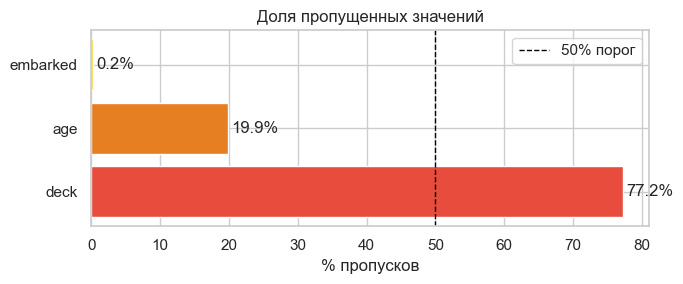

In [3]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_info = missing_pct[missing_pct > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(missing_info.index, missing_info.values, color=['#e74c3c','#e67e22','#f1c40f'])
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='50% порог')
ax.set_xlabel('% пропусков'); ax.set_title('Доля пропущенных значений'); ax.legend()
for i, v in enumerate(missing_info.values):
    ax.text(v + 0.5, i, f'{v}%', va='center')
plt.tight_layout()
fig.savefig(ART / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=['deck'])           # 77% — удаляем

num_imp = SimpleImputer(strategy='median')
df_clean['age'] = num_imp.fit_transform(df_clean[['age']])
print(f'age: заполнено медианой = {num_imp.statistics_[0]:.1f}')

cat_imp = SimpleImputer(strategy='most_frequent')
df_clean['embarked'] = cat_imp.fit_transform(df_clean[['embarked']]).ravel()
print(f"embarked: заполнено модой = '{cat_imp.statistics_[0]}'")

print(f'\nОставшихся пропусков: {df_clean.isnull().sum().sum()}')


age: заполнено медианой = 28.0
embarked: заполнено модой = 'S'

Оставшихся пропусков: 0


## 3. Кодирование категориальных признаков
- **Label Encoding** — для бинарных/ординальных признаков (sex: female=0, male=1).
- **One-Hot Encoding** — для номинальных (embarked → 3 бинарных столбца). Label Encoding нельзя применять к номинальным: вводит ложный порядок.


In [5]:
df_enc = df_clean.copy()

# Label Encoding: sex
le = LabelEncoder()
df_enc['sex_encoded'] = le.fit_transform(df_enc['sex'])
print('sex:', dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding: embarked
df_enc = pd.get_dummies(df_enc, columns=['embarked'], prefix='embarked')
df_enc = df_enc.drop(columns=['sex'])

print('\nСтолбцы после кодирования:', list(df_enc.columns))
display(df_enc.head(3))


sex: {'female': 0, 'male': 1}

Столбцы после кодирования: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_encoded', 'embarked_C', 'embarked_Q', 'embarked_S']


,survived,pclass,age,sibsp,parch,fare,sex_encoded,embarked_C,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,False,False,True
1,1,1,38.0,1,0,71.2833,0,True,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True


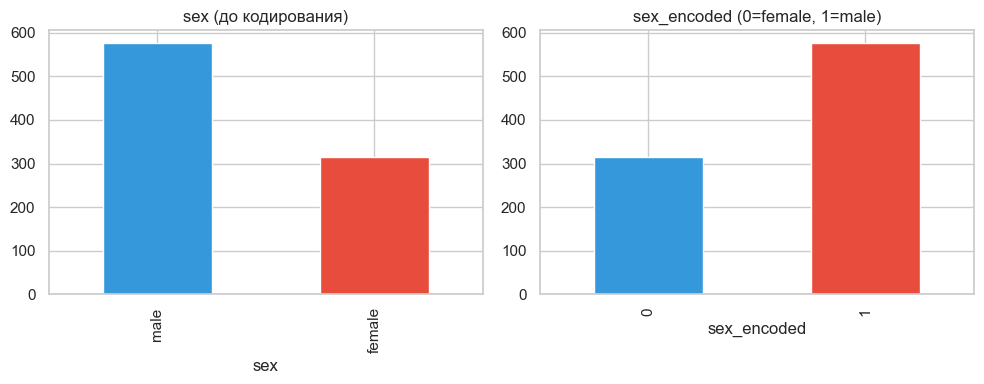

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_clean['sex'].value_counts().plot.bar(ax=axes[0], color=['#3498db','#e74c3c'],
                                         title='sex (до кодирования)')
df_enc['sex_encoded'].value_counts().sort_index().plot.bar(
    ax=axes[1], color=['#3498db','#e74c3c'], title='sex_encoded (0=female, 1=male)')
plt.tight_layout()
fig.savefig(ART / 'label_encoding.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Масштабирование данных
| Метод | Формула | Устойчивость к выбросам |
|---|---|---|
| StandardScaler | (x−μ)/σ | низкая |
| MinMaxScaler | (x−min)/(max−min) | очень низкая |
| **RobustScaler** | (x−Q2)/IQR | **высокая** ← рекомендован для fare |


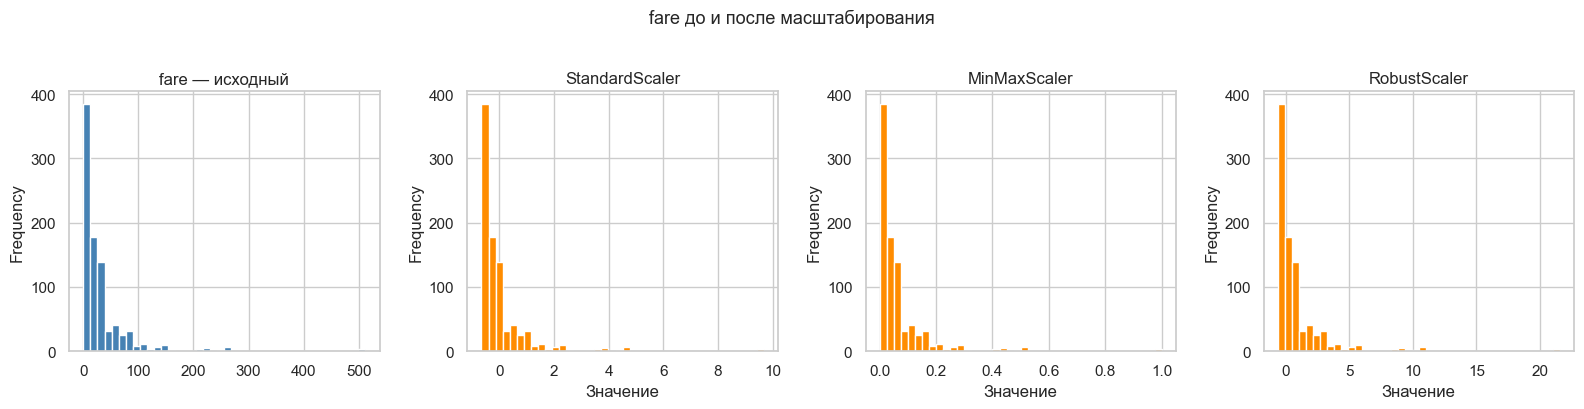

In [7]:
scale_cols = ['age', 'fare', 'sibsp', 'parch']
X = df_enc[scale_cols].copy()

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
}
scaled = {name: pd.DataFrame(s.fit_transform(X), columns=scale_cols)
          for name, s in scalers.items()}

# Гистограммы fare до и после
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
X['fare'].plot.hist(ax=axes[0], bins=40, color='steelblue', title='fare — исходный')
for ax, (name, df_s) in zip(axes[1:], scaled.items()):
    df_s['fare'].plot.hist(ax=ax, bins=40, color='darkorange', title=name)
    ax.set_xlabel('Значение')
plt.suptitle('fare до и после масштабирования', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(ART / 'scaling_fare.png', dpi=150, bbox_inches='tight')
plt.show()


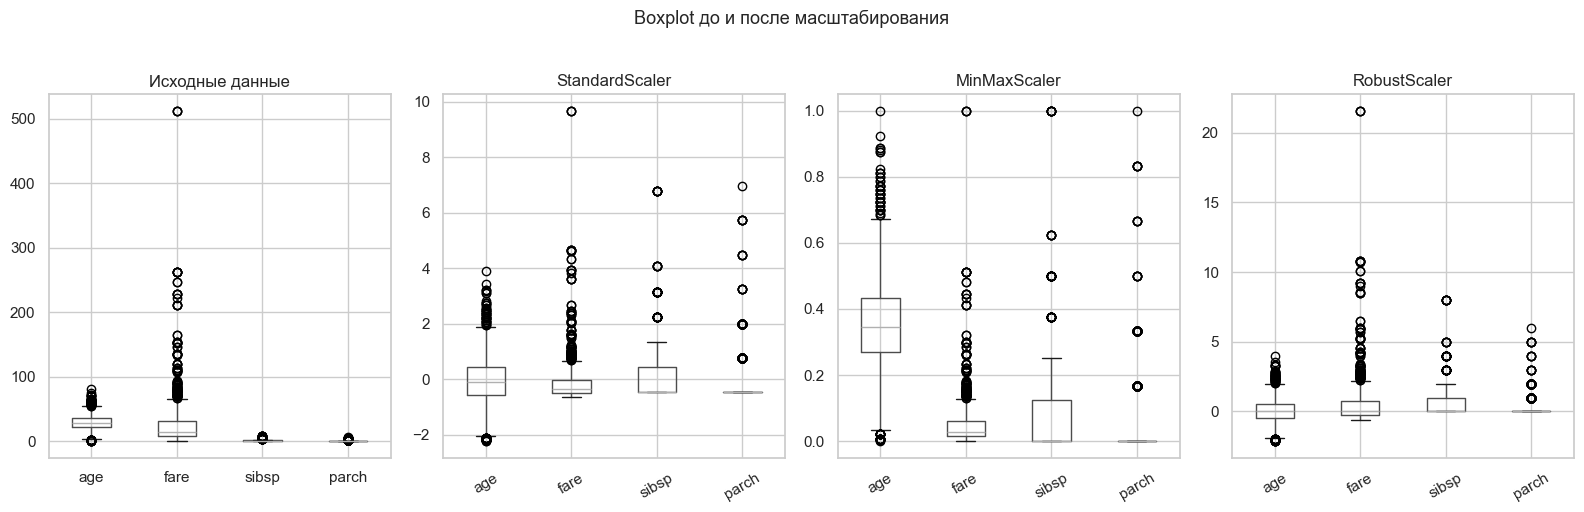

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
X.boxplot(ax=axes[0]); axes[0].set_title('Исходные данные')
for ax, (name, df_s) in zip(axes[1:], scaled.items()):
    df_s.boxplot(ax=ax); ax.set_title(name)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Boxplot до и после масштабирования', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(ART / 'scaling_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
robust = RobustScaler()
X_scaled = pd.DataFrame(
    robust.fit_transform(df_enc[scale_cols]),
    columns=[c + '_scaled' for c in scale_cols]
)
other = [c for c in df_enc.columns if c not in scale_cols]
df_final = pd.concat([df_enc[other].reset_index(drop=True), X_scaled], axis=1)
print('Итоговый датасет:', df_final.shape, '| пропусков:', df_final.isnull().sum().sum())
display(df_final.head(3))
df_final.to_csv(ART / 'titanic_preprocessed.csv', index=False)


Итоговый датасет: (891, 10) | пропусков: 0


,survived,pclass,sex_encoded,embarked_C,embarked_Q,embarked_S,age_scaled,fare_scaled,sibsp_scaled,parch_scaled
0,0,3,1,False,False,True,-0.461538,-0.312011,1.0,0.0
1,1,1,0,True,False,False,0.769231,2.461242,1.0,0.0
2,1,3,0,False,False,True,-0.153846,-0.282777,0.0,0.0


## Выводы
- **Пропуски:** `deck` удалён (77%); `age` заполнен медианой (28 лет); `embarked` — модой ('S').
- **Кодирование:** `sex` → Label Encoding (female=0, male=1); `embarked` → OHE (3 столбца). Label Encoding для номинальных признаков неприменим.
- **Масштабирование:** RobustScaler — оптимален из-за выбросов в `fare`; StandardScaler — при нормальном распределении; MinMaxScaler — при строгом диапазоне [0,1].
- Итоговый датасет: только числовые признаки, пропусков нет — готов к обучению моделей.
